In [7]:
import torch
print(torch.__version__)

2.10.0+cu128


In [9]:
# ============================================================
# 1. Imports
# ============================================================
import json
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from contextlib import nullcontext
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from tensorflow.keras.preprocessing.text import Tokenizer          # kept for preprocessing parity
from tensorflow.keras.preprocessing.sequence import pad_sequences  # kept for preprocessing parity
from sklearn.model_selection import train_test_split
from scipy.stats import spearmanr

# ============================================================
# 2. Device Setup
# ============================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"  GPU : {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# ============================================================
# 3. Load Training Data  (unchanged)
# ============================================================
with open('/content/train.json') as f:
    raw = json.load(f)

def build_story(item):
    return ' '.join([
        item.get('precontext', ''),
        item.get('sentence', ''),
        item.get('ending', '')
    ])

def build_meaning(item):
    return item.get('judged_meaning', '')

items    = list(raw.values())
stories  = [build_story(i)  for i in items]
meanings = [build_meaning(i) for i in items]
labels   = np.array([i['average'] for i in items], dtype=np.float32)
stdevs   = np.array([i['stdev']   for i in items], dtype=np.float32)

# ============================================================
# 4. Tokenization  (unchanged)
# ============================================================
MAX_WORDS = 10000
MAX_LEN   = 150

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(stories + meanings)

X_story = pad_sequences(
    tokenizer.texts_to_sequences(stories),
    maxlen=MAX_LEN, padding='post'
)
X_mean = pad_sequences(
    tokenizer.texts_to_sequences(meanings),
    maxlen=MAX_LEN, padding='post'
)

Xs_train, Xs_val, Xm_train, Xm_val, y_train, y_val, s_train, s_val = train_test_split(
    X_story, X_mean, labels, stdevs,
    test_size=0.15, random_state=42
)

# ============================================================
# 5. Load GloVe Embeddings  (unchanged logic)
# ============================================================
GLOVE_PATH = '/content/glove.6B.100d.txt'
EMBED_DIM  = 100

if not os.path.exists(GLOVE_PATH):
    raise FileNotFoundError("Download GloVe first: glove.6B.100d.txt")

embeddings_index = {}
with open(GLOVE_PATH, encoding='utf8') as f:
    for line in f:
        values = line.split()
        embeddings_index[values[0]] = np.asarray(values[1:], dtype='float32')

word_index = tokenizer.word_index
num_words  = min(MAX_WORDS, len(word_index) + 1)

embedding_matrix = np.zeros((num_words, EMBED_DIM), dtype=np.float32)
for word, i in word_index.items():
    if i < num_words and word in embeddings_index:
        embedding_matrix[i] = embeddings_index[word]

# ============================================================
# 6. Dataset
# ============================================================
class AmbiStoryDataset(Dataset):
    def __init__(self, X_story, X_mean, labels, stdevs):
        self.X_story = torch.tensor(X_story, dtype=torch.long)
        self.X_mean  = torch.tensor(X_mean,  dtype=torch.long)
        self.labels  = torch.tensor(labels,  dtype=torch.float32)
        self.stdevs  = torch.tensor(stdevs,  dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (
            self.X_story[idx],
            self.X_mean[idx],
            self.labels[idx],
            self.stdevs[idx]
        )

# Sample weights: w = 1 / stdev^2, normalised
train_weights = 1.0 / np.maximum(s_train, 1.0) ** 2
train_weights = train_weights / train_weights.mean()

train_dataset = AmbiStoryDataset(Xs_train, Xm_train, y_train, s_train)
val_dataset   = AmbiStoryDataset(Xs_val,   Xm_val,   y_val,   s_val)

# WeightedRandomSampler applies Gaussian weighting during training
sampler = WeightedRandomSampler(
    weights=torch.tensor(train_weights, dtype=torch.float64),
    num_samples=len(train_dataset),
    replacement=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    sampler=sampler,
    pin_memory=(device.type == 'cuda'),   # async CPU→GPU transfer
    num_workers=2
)
val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    pin_memory=(device.type == 'cuda'),
    num_workers=2
)

# ============================================================
# 7. Encoder (BiSimpleRNN — no attention, GloVe trainable)
# ============================================================
class BiRNNEncoder(nn.Module):
    def __init__(self, num_words, embed_dim, embedding_matrix,
                 rnn_units, num_layers, dropout, l2_reg):
        super().__init__()

        self.embedding = nn.Embedding(num_words, embed_dim, padding_idx=0)
        self.embedding.weight = nn.Parameter(
            torch.tensor(embedding_matrix, dtype=torch.float32)
        )                                           # GloVe weights, trainable

        self.rnn = nn.RNN(
            input_size=embed_dim,
            hidden_size=rnn_units,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.dropout = nn.Dropout(dropout)
        self._l2_reg = l2_reg                       # stored for use in loss if needed

    def forward(self, x):
        x = self.embedding(x)                       # (B, L, E)
        x = self.dropout(x)
        out, _ = self.rnn(x)                        # (B, L, 2*rnn_units)
        x = out.mean(dim=1)                         # GlobalAveragePooling equivalent
        return x

# ============================================================
# 8. Dual-Encoder Model
# ============================================================
class DualEncoderModel(nn.Module):
    def __init__(self, num_words, embed_dim, embedding_matrix,
                 rnn_units=128, num_layers=1, dropout=0.3,
                 dense_units=128, l2_reg=1e-4):
        super().__init__()

        encoder_args = (num_words, embed_dim, embedding_matrix,
                        rnn_units, num_layers, dropout, l2_reg)

        self.story_encoder   = BiRNNEncoder(*encoder_args)
        self.meaning_encoder = BiRNNEncoder(*encoder_args)

        combined_dim = rnn_units * 2 * 3            # story + meaning + |diff|

        self.head = nn.Sequential(
            nn.Linear(combined_dim, dense_units),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(dense_units, 1)
        )

    def forward(self, story, meaning):
        sv = self.story_encoder(story)              # (B, 2*rnn_units)
        mv = self.meaning_encoder(meaning)          # (B, 2*rnn_units)
        diff = torch.abs(sv - mv)
        combined = torch.cat([sv, mv, diff], dim=1) # (B, 6*rnn_units)
        return self.head(combined).squeeze(1)       # (B,)

# ============================================================
# 9. Weighted MSE Loss  (Gaussian: weight = 1 / stdev^2)
# ============================================================
def weighted_mse_loss(preds, targets, weights):
    # weights already = 1/stdev^2, normalised
    return (weights * (preds - targets) ** 2).mean()

# ============================================================
# 10. Training Loop
# ============================================================
def get_amp_autocast(device):
    if device.type != 'cuda':
        return nullcontext()
    if hasattr(torch, 'autocast'):
        return torch.autocast(device_type='cuda', dtype=torch.float16, enabled=True)
    return torch.cuda.amp.autocast(dtype=torch.float16, enabled=True)


def get_grad_scaler(device):
    amp_enabled = (device.type == 'cuda')
    if hasattr(torch, 'amp') and hasattr(torch.amp, 'GradScaler'):
        return torch.amp.GradScaler(device.type, enabled=amp_enabled)
    return torch.cuda.amp.GradScaler(enabled=amp_enabled)


def train_one_epoch(model, loader, optimizer, scaler):
    model.train()
    total_loss = 0.0

    for story, meaning, label, stdev in loader:
        # Non-blocking async transfers to GPU
        story   = story.to(device, non_blocking=True)
        meaning = meaning.to(device, non_blocking=True)
        label   = label.to(device, non_blocking=True)
        stdev   = stdev.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)       # faster than zero_grad()

        with get_amp_autocast(device):  # AMP — auto mixed precision
            preds = model(story, meaning)
            w     = 1.0 / torch.clamp(stdev, min=1.0) ** 2
            w     = w / w.mean()
            loss  = weighted_mse_loss(preds, label, w)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # gradient clipping
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

    return total_loss / len(loader)

@torch.no_grad()
def evaluate_epoch(model, loader):
    model.eval()
    total_loss = 0.0

    for story, meaning, label, stdev in loader:
        story   = story.to(device, non_blocking=True)
        meaning = meaning.to(device, non_blocking=True)
        label   = label.to(device, non_blocking=True)
        stdev   = stdev.to(device, non_blocking=True)

        preds = model(story, meaning)
        w     = 1.0 / torch.clamp(stdev, min=1.0) ** 2
        w     = w / w.mean()
        loss  = weighted_mse_loss(preds, label, w)
        total_loss += loss.item()

    return total_loss / len(loader)

# ============================================================
# 11. Instantiate Model, Optimizer, Scheduler
# ============================================================
model = DualEncoderModel(
    num_words=num_words,
    embed_dim=EMBED_DIM,
    embedding_matrix=embedding_matrix,
    rnn_units=128,
    num_layers=1,
    dropout=0.3,
    dense_units=128,
    l2_reg=1e-4
).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.5
)
scaler = get_grad_scaler(device)  # AMP scaler (version-safe)

# ============================================================
# 12. Run Training with Early Stopping
# ============================================================
EPOCHS        = 30
PATIENCE      = 5
best_val_loss = float('inf')
patience_ctr  = 0
best_weights  = None

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, scaler)
    val_loss   = evaluate_epoch(model, val_loader)
    scheduler.step(val_loss)

    print(f"Epoch {epoch:02d} | train_loss: {train_loss:.4f} | val_loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_weights  = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_ctr  = 0
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

# Restore best weights
model.load_state_dict({k: v.to(device) for k, v in best_weights.items()})

# ============================================================
# 13. Evaluation (SemEval Metrics — unchanged)
# ============================================================
@torch.no_grad()
def evaluate(model, Xs, Xm, y=None, s=None, compute_metrics=True):
    model.eval()
    if y is None:
        y = np.zeros(len(Xs), dtype=np.float32)
    if s is None:
        s = np.ones(len(Xs), dtype=np.float32)

    ds     = AmbiStoryDataset(Xs, Xm, y, s)
    loader = DataLoader(ds, batch_size=64, shuffle=False,
                        pin_memory=(device.type == 'cuda'))

    all_preds = []
    for story, meaning, _, _ in loader:
        story   = story.to(device, non_blocking=True)
        meaning = meaning.to(device, non_blocking=True)
        preds   = model(story, meaning)
        all_preds.append(preds.cpu().numpy())

    preds = np.clip(np.concatenate(all_preds), 1, 5)
    if compute_metrics:
        s = np.maximum(s, 1.0)

        sp = spearmanr(y, preds).correlation
        print("Spearman r           :", sp)
        print("Accuracy within std  :", np.mean(np.abs(preds - y) <= s))
    return preds

print("\n── Validation Results ──")
val_preds = evaluate(model, Xs_val, Xm_val, y_val, s_val)

# ============================================================
# 14. Predict on Test Set
# ============================================================
with open('/content/test.json') as f:
    test_raw = json.load(f)

test_items = list(test_raw.values())
test_story = pad_sequences(
    tokenizer.texts_to_sequences([build_story(i)  for i in test_items]),
    maxlen=MAX_LEN, padding='post'
)
test_mean = pad_sequences(
    tokenizer.texts_to_sequences([build_meaning(i) for i in test_items]),
    maxlen=MAX_LEN, padding='post'
)

dummy_labels = np.ones(len(test_items), dtype=np.float32)
dummy_stdevs = np.ones(len(test_items), dtype=np.float32)

test_preds = evaluate(
    model,
    test_story,
    test_mean,
    dummy_labels,
    dummy_stdevs,
    compute_metrics=False
)

print("\nSample Test Predictions:")
for i in range(min(10, len(test_preds))):
    print(f"Sample {i+1}: {test_preds[i]:.3f}")

Using device: cuda
  GPU : Tesla T4
  VRAM: 15.6 GB
Epoch 01 | train_loss: 3.2298 | val_loss: 1.8656
Epoch 02 | train_loss: 2.0129 | val_loss: 1.7155
Epoch 03 | train_loss: 1.9402 | val_loss: 1.6970
Epoch 04 | train_loss: 1.8879 | val_loss: 1.6736
Epoch 05 | train_loss: 1.8640 | val_loss: 1.6591
Epoch 06 | train_loss: 1.9024 | val_loss: 1.6684
Epoch 07 | train_loss: 1.6159 | val_loss: 1.6188
Epoch 08 | train_loss: 1.6431 | val_loss: 2.2083
Epoch 09 | train_loss: 1.5902 | val_loss: 1.7662
Epoch 10 | train_loss: 1.3981 | val_loss: 1.7473
Epoch 11 | train_loss: 1.2577 | val_loss: 1.8383
Epoch 12 | train_loss: 1.2973 | val_loss: 1.7327
Early stopping at epoch 12

── Validation Results ──
Spearman r           : 0.23711147355894957
Accuracy within std  : 0.6169590643274854

Sample Test Predictions:
Sample 1: 1.917
Sample 2: 3.387
Sample 3: 2.007
Sample 4: 3.486
Sample 5: 1.921
Sample 6: 3.386
Sample 7: 2.287
Sample 8: 3.769
Sample 9: 2.284
Sample 10: 3.741


Spearman r           : 0.23711147355894957
Accuracy within std  : 0.6169590643274854


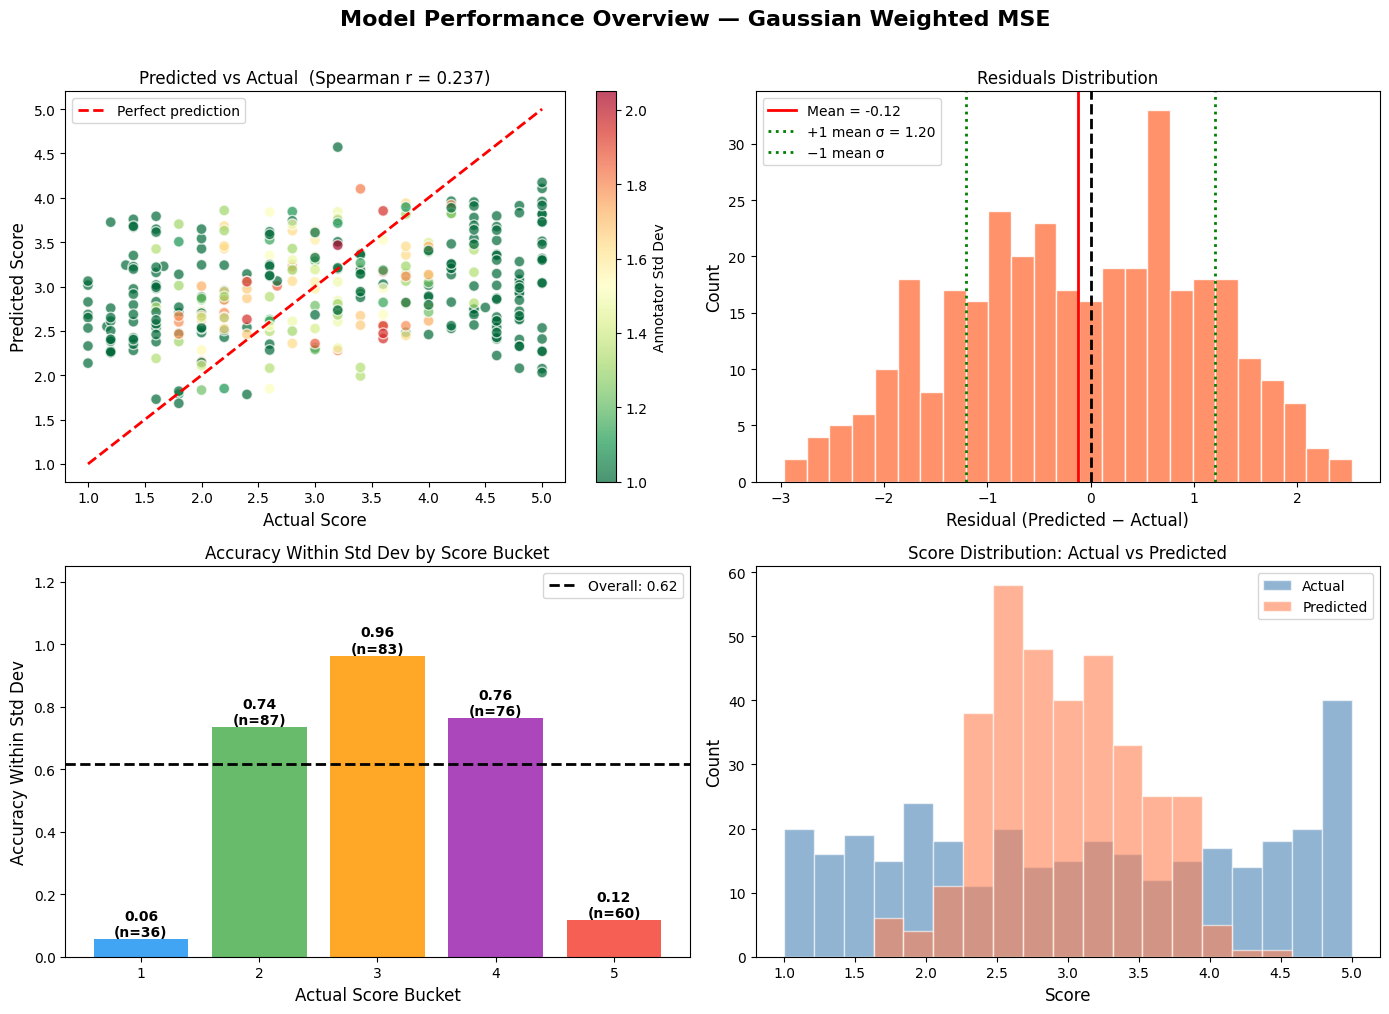

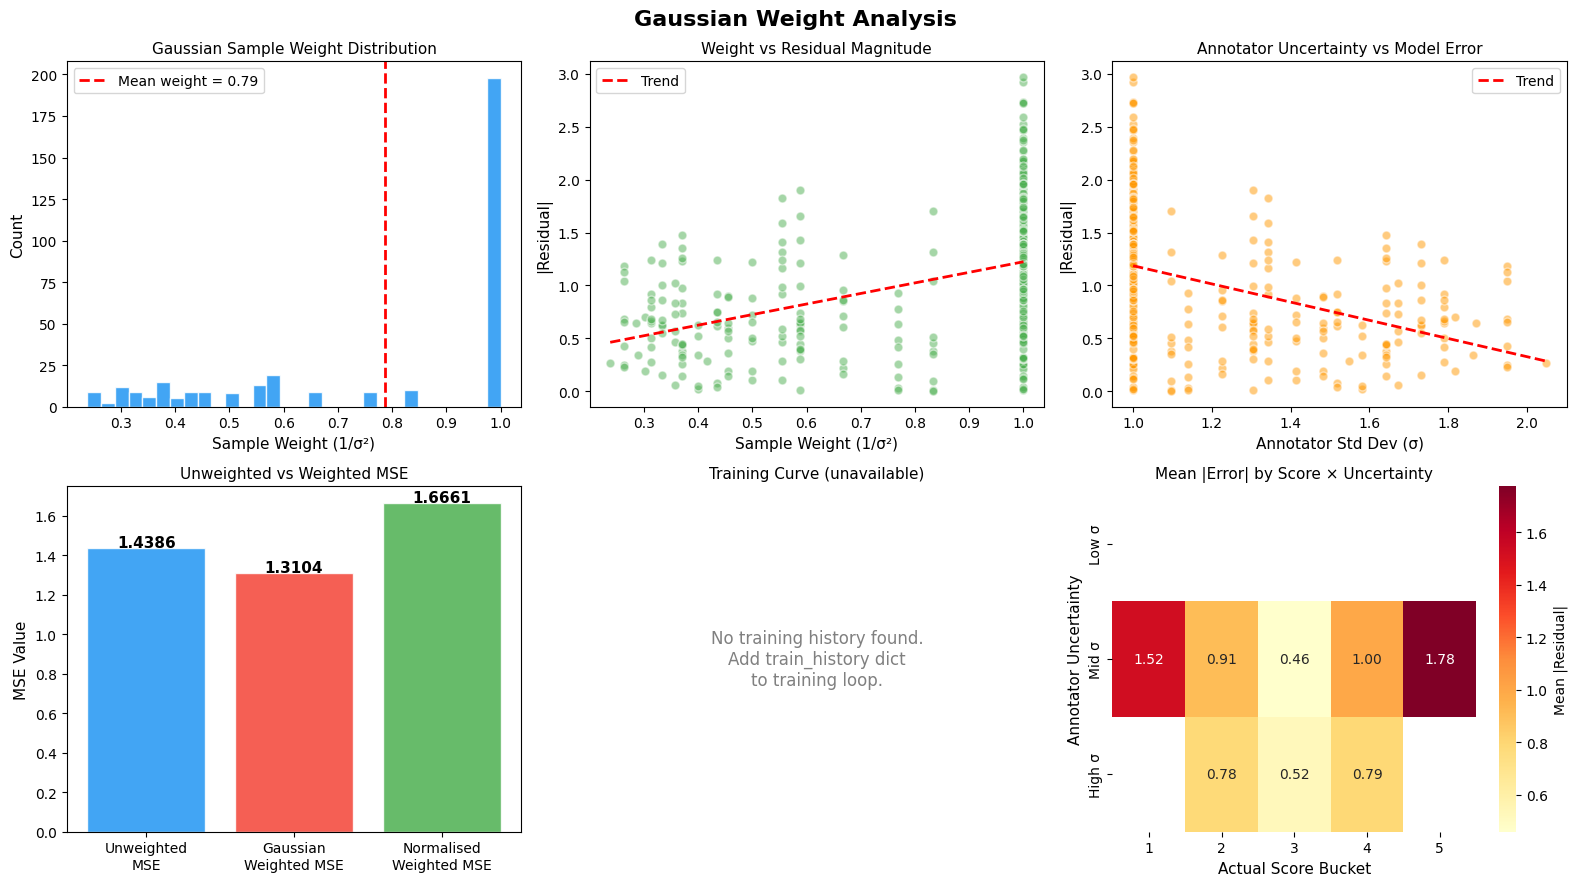

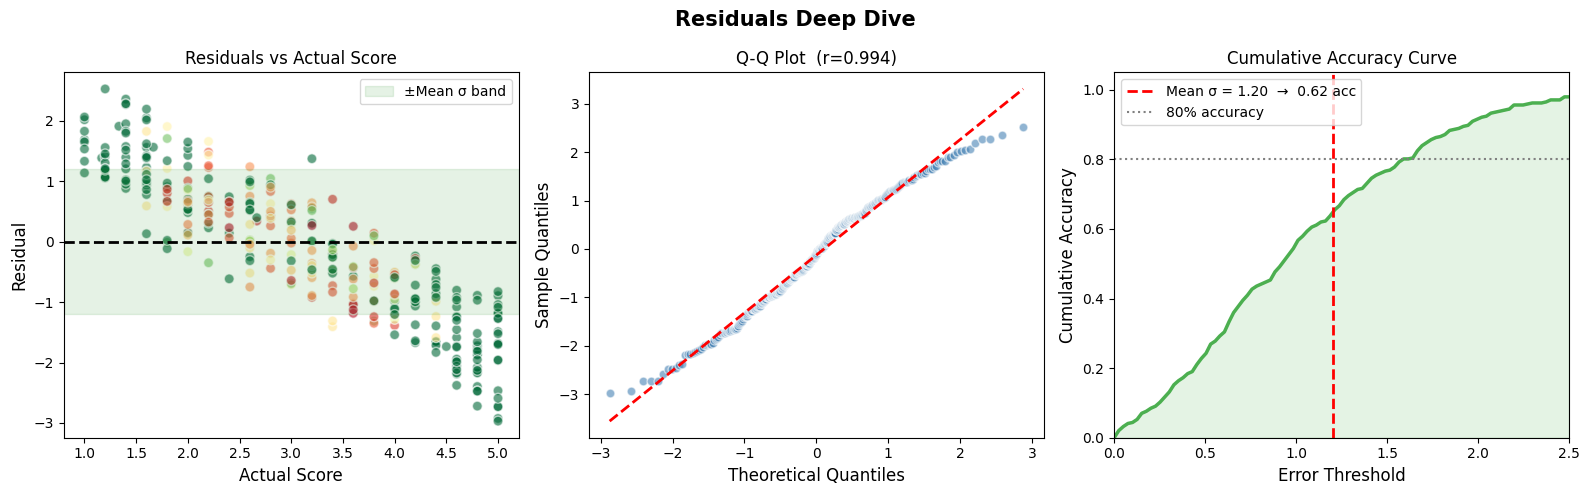

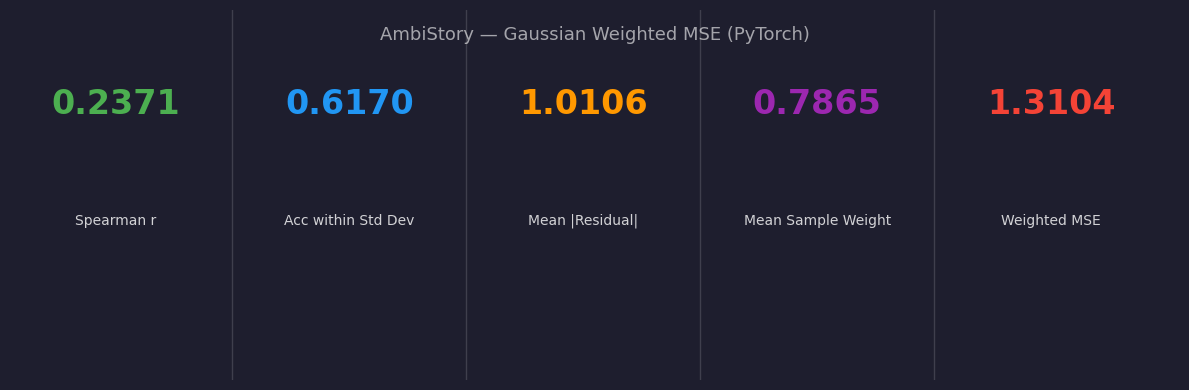


✓ Saved:
  /content/performance_overview.png
  /content/gaussian_weight_analysis.png
  /content/residuals_deep_dive.png
  /content/summary_card.png


In [13]:
# ============================================================
# Visualization — Gaussian Weighted MSE (PyTorch)
# Run AFTER training. Requires: model, val_loader, y_val, s_val,
#                               train_history (dict built below)
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
from scipy.stats import spearmanr

# ── Collect val predictions ────────────────────────────────────────────────
val_preds  = evaluate(model, Xs_val, Xm_val, y_val, s_val)   # already clipped [1,5]
stdevs     = np.maximum(s_val, 1.0)
residuals  = val_preds - y_val
within     = np.abs(residuals) <= stdevs
spear      = spearmanr(y_val, val_preds).correlation
weights    = 1.0 / stdevs ** 2                                 # Gaussian sample weights

# ── Rebuild train_history if not already collected ────────────────────────
# If you want live curves, replace the training loop block (Section 12) with:
#
#   train_history = {'train_loss': [], 'val_loss': []}
#   for epoch in ...:
#       tl = train_one_epoch(...)
#       vl = evaluate_epoch(...)
#       train_history['train_loss'].append(tl)
#       train_history['val_loss'].append(vl)
#
# This script will still run without it (curves panel is skipped gracefully).
has_history = 'train_history' in dir() or 'train_history' in globals()

# ═══════════════════════════════════════════════════════════════════════════
# FIGURE 1 — Model Performance Overview  (identical structure to original)
# ═══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Model Performance Overview — Gaussian Weighted MSE',
             fontsize=16, fontweight='bold', y=1.01)

# ── 1. Predicted vs Actual ─────────────────────────────────────────────────
ax = axes[0, 0]
sc = ax.scatter(y_val, val_preds, c=stdevs, cmap='RdYlGn_r',
                alpha=0.7, edgecolors='white', s=60)
plt.colorbar(sc, ax=ax, label='Annotator Std Dev')
ax.plot([1, 5], [1, 5], 'r--', lw=2, label='Perfect prediction')
ax.set_xlabel('Actual Score',    fontsize=12)
ax.set_ylabel('Predicted Score', fontsize=12)
ax.set_title(f'Predicted vs Actual  (Spearman r = {spear:.3f})', fontsize=12)
ax.legend(); ax.set_xlim(0.8, 5.2); ax.set_ylim(0.8, 5.2)
# Colour encodes annotator uncertainty — high stdev = red = down-weighted by Gaussian loss

# ── 2. Residuals Distribution ─────────────────────────────────────────────
ax = axes[0, 1]
ax.hist(residuals, bins=25, color='coral', edgecolor='white', alpha=0.85)
ax.axvline(0,               color='black', linestyle='--', lw=2)
ax.axvline(residuals.mean(), color='red',   linestyle='-',  lw=2,
           label=f'Mean = {residuals.mean():.2f}')
ax.axvline( stdevs.mean(),  color='green',  linestyle=':',  lw=2,
           label=f'+1 mean σ = {stdevs.mean():.2f}')
ax.axvline(-stdevs.mean(),  color='green',  linestyle=':',  lw=2,
           label=f'−1 mean σ')
ax.set_xlabel('Residual (Predicted − Actual)', fontsize=12)
ax.set_ylabel('Count',                         fontsize=12)
ax.set_title('Residuals Distribution',         fontsize=12)
ax.legend()

# ── 3. Accuracy Within Std Dev per Score Bucket ────────────────────────────
ax = axes[1, 0]
buckets     = [1, 2, 3, 4, 5]
bucket_acc  = []
bucket_n    = []
for b in buckets:
    mask = (np.round(y_val) == b)
    bucket_acc.append(within[mask].mean() if mask.sum() > 0 else 0)
    bucket_n.append(mask.sum())

colors = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336']
bars   = ax.bar([str(b) for b in buckets], bucket_acc,
                color=colors, alpha=0.85)
ax.axhline(within.mean(), color='black', linestyle='--', lw=2,
           label=f'Overall: {within.mean():.2f}')
for bar, val, n in zip(bars, bucket_acc, bucket_n):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.2f}\n(n={n})', ha='center', fontsize=10, fontweight='bold')
ax.set_xlabel('Actual Score Bucket', fontsize=12)
ax.set_ylabel('Accuracy Within Std Dev', fontsize=12)
ax.set_title('Accuracy Within Std Dev by Score Bucket', fontsize=12)
ax.set_ylim(0, 1.25); ax.legend()

# ── 4. Score Distribution: Actual vs Predicted ────────────────────────────
ax = axes[1, 1]
bins = np.linspace(1, 5, 20)
ax.hist(y_val,     bins=bins, alpha=0.6, color='steelblue',
        label='Actual',    edgecolor='white')
ax.hist(val_preds, bins=bins, alpha=0.6, color='coral',
        label='Predicted', edgecolor='white')
ax.set_xlabel('Score', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Score Distribution: Actual vs Predicted', fontsize=12)
ax.legend()

plt.tight_layout()
plt.savefig('/content/performance_overview.png', dpi=150, bbox_inches='tight')
plt.show()

# ═══════════════════════════════════════════════════════════════════════════
# FIGURE 2 — Gaussian Weight Analysis (replaces tuner HP scatter)
# ═══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Gaussian Weight Analysis', fontsize=16, fontweight='bold')

# ── 1. Sample Weight Distribution ─────────────────────────────────────────
ax = axes[0, 0]
ax.hist(weights, bins=30, color='#2196F3', edgecolor='white', alpha=0.85)
ax.axvline(weights.mean(), color='red', lw=2, linestyle='--',
           label=f'Mean weight = {weights.mean():.2f}')
ax.set_xlabel('Sample Weight (1/σ²)', fontsize=11)
ax.set_ylabel('Count',                fontsize=11)
ax.set_title('Gaussian Sample Weight Distribution', fontsize=11)
ax.legend()

# ── 2. Weight vs Residual Magnitude ───────────────────────────────────────
ax = axes[0, 1]
ax.scatter(weights, np.abs(residuals), alpha=0.5, color='#4CAF50',
           edgecolors='white', s=40)
ax.set_xlabel('Sample Weight (1/σ²)',    fontsize=11)
ax.set_ylabel('|Residual|',              fontsize=11)
ax.set_title('Weight vs Residual Magnitude', fontsize=11)
# Ideal: high-weight (low stdev) samples should have small residuals
z = np.polyfit(weights, np.abs(residuals), 1)
xline = np.linspace(weights.min(), weights.max(), 100)
ax.plot(xline, np.poly1d(z)(xline), 'r--', lw=2, label='Trend')
ax.legend()

# ── 3. Stdev vs Absolute Error ─────────────────────────────────────────────
ax = axes[0, 2]
ax.scatter(stdevs, np.abs(residuals), alpha=0.5, color='#FF9800',
           edgecolors='white', s=40)
ax.set_xlabel('Annotator Std Dev (σ)', fontsize=11)
ax.set_ylabel('|Residual|',            fontsize=11)
ax.set_title('Annotator Uncertainty vs Model Error', fontsize=11)
z2 = np.polyfit(stdevs, np.abs(residuals), 1)
xline2 = np.linspace(stdevs.min(), stdevs.max(), 100)
ax.plot(xline2, np.poly1d(z2)(xline2), 'r--', lw=2, label='Trend')
ax.legend()

# ── 4. Weighted vs Unweighted Residual Comparison ─────────────────────────
ax = axes[1, 0]
unweighted_mse = np.mean(residuals**2)
weighted_mse   = np.mean(weights * residuals**2)
norm_weights   = weights / weights.mean()
norm_w_mse     = np.mean(norm_weights * residuals**2)

ax.bar(['Unweighted\nMSE', 'Gaussian\nWeighted MSE', 'Normalised\nWeighted MSE'],
       [unweighted_mse, weighted_mse, norm_w_mse],
       color=['#2196F3','#F44336','#4CAF50'], alpha=0.85, edgecolor='white')
ax.set_ylabel('MSE Value', fontsize=11)
ax.set_title('Unweighted vs Weighted MSE', fontsize=11)
for i, v in enumerate([unweighted_mse, weighted_mse, norm_w_mse]):
    ax.text(i, v + 0.005, f'{v:.4f}', ha='center', fontsize=11, fontweight='bold')

# ── 5. Training Curve (if history collected) ──────────────────────────────
ax = axes[1, 1]
if has_history:
    epochs_range = range(1, len(train_history['train_loss']) + 1)
    ax.plot(epochs_range, train_history['train_loss'],
            color='steelblue', lw=2, label='Train Loss')
    ax.plot(epochs_range, train_history['val_loss'],
            color='coral',     lw=2, label='Val Loss',  linestyle='--')
    ax.set_xlabel('Epoch',     fontsize=11)
    ax.set_ylabel('Loss',      fontsize=11)
    ax.set_title('Training & Validation Loss', fontsize=11)
    ax.legend()
else:
    ax.text(0.5, 0.5, 'No training history found.\nAdd train_history dict\nto training loop.',
            ha='center', va='center', transform=ax.transAxes,
            fontsize=12, color='gray')
    ax.set_title('Training Curve (unavailable)', fontsize=11)
    ax.axis('off')

# ── 6. Prediction Error Heatmap by (actual_bucket × stdev_bucket) ─────────
ax = axes[1, 2]
score_buckets = [1, 2, 3, 4, 5]
stdev_bins = np.percentile(stdevs, [0, 33, 66, 100])
stdev_labels = ['Low σ', 'Mid σ', 'High σ']

heatmap_data = np.full((3, len(score_buckets)), np.nan)
for si in range(3):
        if si < 2:
                smask = (stdevs >= stdev_bins[si]) & (stdevs < stdev_bins[si+1])
        else:
                smask = (stdevs >= stdev_bins[si]) & (stdevs <= stdev_bins[si+1])

        for bi, b in enumerate(score_buckets):
                bmask = (np.round(y_val) == b)
                mask  = smask & bmask
                heatmap_data[si, bi] = np.abs(residuals[mask]).mean() if mask.sum() > 0 else np.nan

sns.heatmap(heatmap_data, ax=ax,
            xticklabels=score_buckets,
            yticklabels=stdev_labels,
            annot=True, fmt='.2f', cmap='YlOrRd',
            cbar_kws={'label': 'Mean |Residual|'})
ax.set_xlabel('Actual Score Bucket', fontsize=11)
ax.set_ylabel('Annotator Uncertainty', fontsize=11)
ax.set_title('Mean |Error| by Score × Uncertainty', fontsize=11)

plt.tight_layout()
plt.savefig('/content/gaussian_weight_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# ═══════════════════════════════════════════════════════════════════════════
# FIGURE 3 — Residuals Deep Dive  (replaces Top 10 Trials bar chart)
# ═══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Residuals Deep Dive', fontsize=15, fontweight='bold')

# ── 1. Residuals vs Actual Score ──────────────────────────────────────────
ax = axes[0]
ax.scatter(y_val, residuals, c=weights, cmap='RdYlGn',
           alpha=0.6, edgecolors='white', s=50)
ax.axhline(0, color='black', lw=2, linestyle='--')
ax.fill_between([0.8, 5.2], -stdevs.mean(), stdevs.mean(),
                alpha=0.1, color='green', label='±Mean σ band')
ax.set_xlabel('Actual Score',             fontsize=12)
ax.set_ylabel('Residual',                 fontsize=12)
ax.set_title('Residuals vs Actual Score', fontsize=12)
ax.set_xlim(0.8, 5.2); ax.legend()

# ── 2. Q-Q Plot of Residuals ──────────────────────────────────────────────
ax = axes[1]
from scipy import stats
(osm, osr), (slope, intercept, r) = stats.probplot(residuals, dist='norm')
ax.scatter(osm, osr, color='steelblue', alpha=0.6, s=40, edgecolors='white')
ax.plot(osm, slope*np.array(osm) + intercept, 'r--', lw=2)
ax.set_xlabel('Theoretical Quantiles', fontsize=12)
ax.set_ylabel('Sample Quantiles',      fontsize=12)
ax.set_title(f'Q-Q Plot  (r={r:.3f})',  fontsize=12)

# ── 3. Cumulative Accuracy Curve ──────────────────────────────────────────
ax = axes[2]
thresholds = np.linspace(0, 2.5, 100)
cum_acc    = [np.mean(np.abs(residuals) <= t) for t in thresholds]
ax.plot(thresholds, cum_acc, color='#4CAF50', lw=2.5)
ax.axvline(stdevs.mean(), color='red', lw=2, linestyle='--',
           label=f'Mean σ = {stdevs.mean():.2f}  →  {np.mean(within):.2f} acc')
ax.axhline(0.8, color='gray', lw=1.5, linestyle=':', label='80% accuracy')
ax.fill_between(thresholds, cum_acc, alpha=0.15, color='#4CAF50')
ax.set_xlabel('Error Threshold',       fontsize=12)
ax.set_ylabel('Cumulative Accuracy',   fontsize=12)
ax.set_title('Cumulative Accuracy Curve', fontsize=12)
ax.set_xlim(0, 2.5); ax.set_ylim(0, 1.05)
ax.legend()

plt.tight_layout()
plt.savefig('/content/residuals_deep_dive.png', dpi=150, bbox_inches='tight')
plt.show()

# ═══════════════════════════════════════════════════════════════════════════
# FIGURE 4 — Summary Card  (unchanged structure)
# ═══════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(12, 4))
fig.patch.set_facecolor('#1E1E2E')
ax  = fig.add_subplot(111)
ax.set_facecolor('#1E1E2E'); ax.axis('off')

mae_val = np.mean(np.abs(residuals))
metrics = [
    ('Spearman r',           f'{spear:.4f}',          '#4CAF50'),
    ('Acc within Std Dev',   f'{within.mean():.4f}',  '#2196F3'),
    ('Mean |Residual|',      f'{mae_val:.4f}',         '#FF9800'),
    ('Mean Sample Weight',   f'{weights.mean():.4f}',  '#9C27B0'),
    ('Weighted MSE',         f'{np.mean(weights * residuals**2):.4f}', '#F44336'),
]

for i, (label, value, color) in enumerate(metrics):
    x = 0.09 + i * 0.20
    ax.text(x, 0.72, value, transform=ax.transAxes,
            fontsize=24, fontweight='bold', color=color, ha='center')
    ax.text(x, 0.42, label, transform=ax.transAxes,
            fontsize=10, color='white', ha='center', alpha=0.8)
    if i < len(metrics) - 1:
        ax.axvline(x + 0.10, color='white', alpha=0.15, lw=1)

ax.text(0.5, 0.92, 'AmbiStory — Gaussian Weighted MSE (PyTorch)',
        transform=ax.transAxes, fontsize=13, color='white',
        ha='center', alpha=0.6)

plt.tight_layout()
plt.savefig('/content/summary_card.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

print("\n✓ Saved:")
print("  /content/performance_overview.png")
print("  /content/gaussian_weight_analysis.png")
print("  /content/residuals_deep_dive.png")
print("  /content/summary_card.png")